# ARIMA 3: Reforço, SARIMA e Introdução ao ARIMAX 
- Revisão / Reforço:
    - AR, MA, ARMA e ARIMA
    - Identificação de AR e MA através do ACF e PACF
    - Modelos incompletos
    - Escrevendo fórmulas de previsão

- SARIMA
- Introdução ao ARIMAX:
    - Atenções necessárias
    - Tipos de variáveis
    - CCF


In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
from funcoes import all_ac, plot_forecast, teste_estacionariedade, diagnostico, compara_previsoes
plt.rcParams["figure.figsize"] = [12, 5]

## Modelos Incompletos

Modelo da última aula:

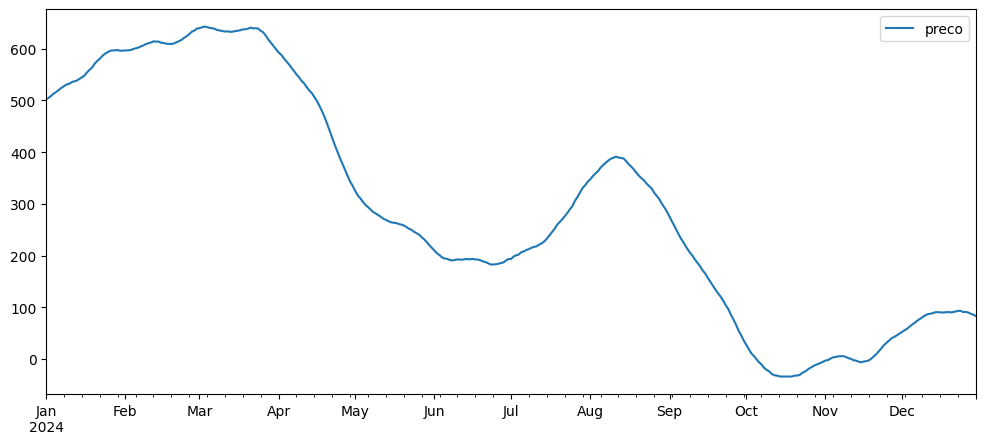

In [2]:
Y = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/ARIMA_Exemplo.csv')
Y.index = pd.date_range(start='2024-01-01', periods = 365)
Y.plot()
plt.show()

In [3]:
teste_estacionariedade(Y)

('Não Estacionário', 'Não Estacionário')

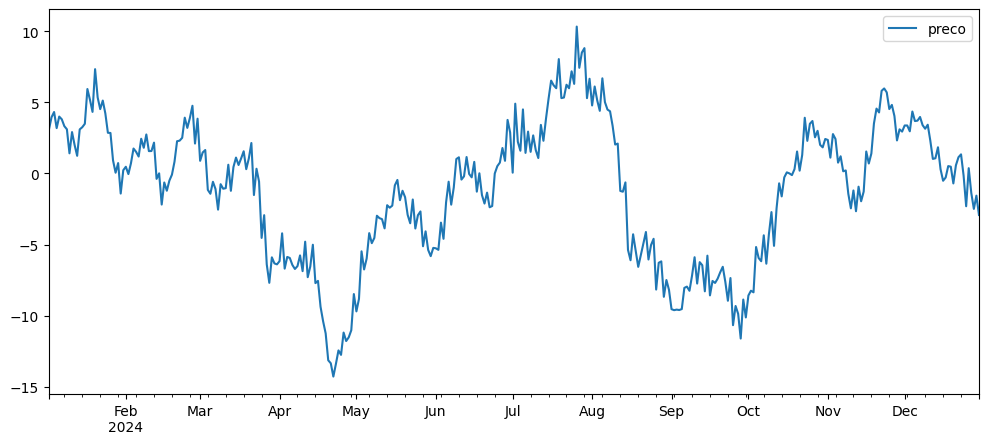

('Estacionário', 'Estacionário')

In [4]:
primeira_ordem = Y.diff().dropna()
primeira_ordem.plot()
plt.show()
teste_estacionariedade(primeira_ordem)

                               SARIMAX Results                                
Dep. Variable:                  preco   No. Observations:                  365
Model:                 ARIMA(2, 1, 3)   Log Likelihood                -514.589
Date:                Tue, 11 Mar 2025   AIC                           1041.178
Time:                        11:37:31   BIC                           1064.561
Sample:                    01-01-2024   HQIC                          1050.472
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5211      0.053      9.863      0.000       0.418       0.625
ar.L2          0.4295      0.054      7.886      0.000       0.323       0.536
ma.L1         -0.0321      0.025     -1.286      0.1

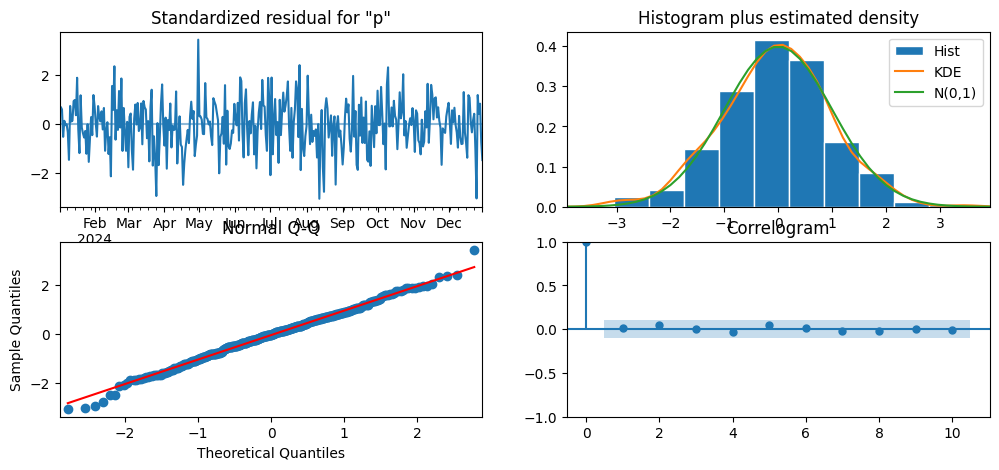

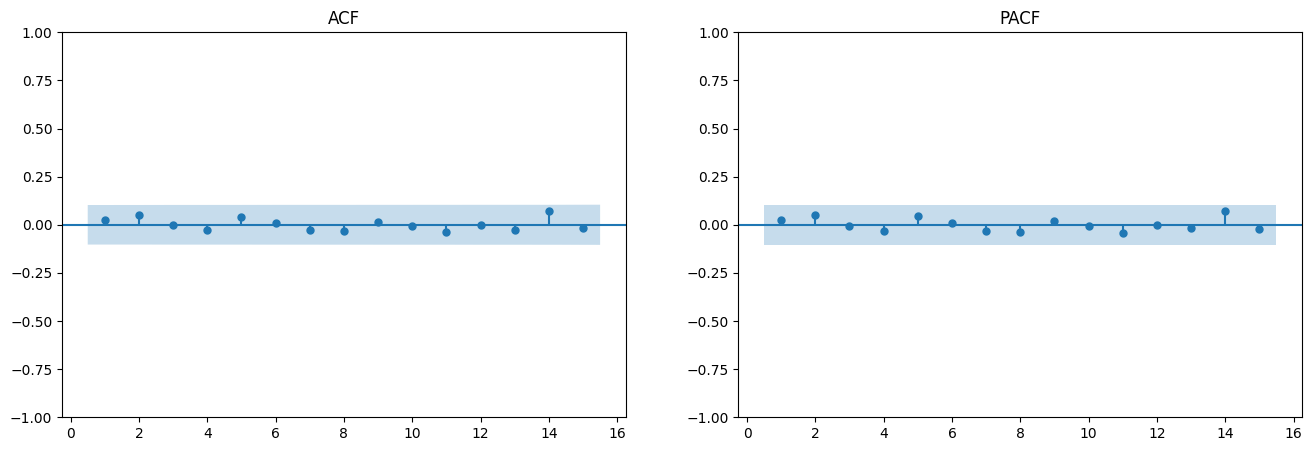

In [5]:
model = ARIMA(Y, order=(2, 1, 3)).fit()
diagnostico(model)

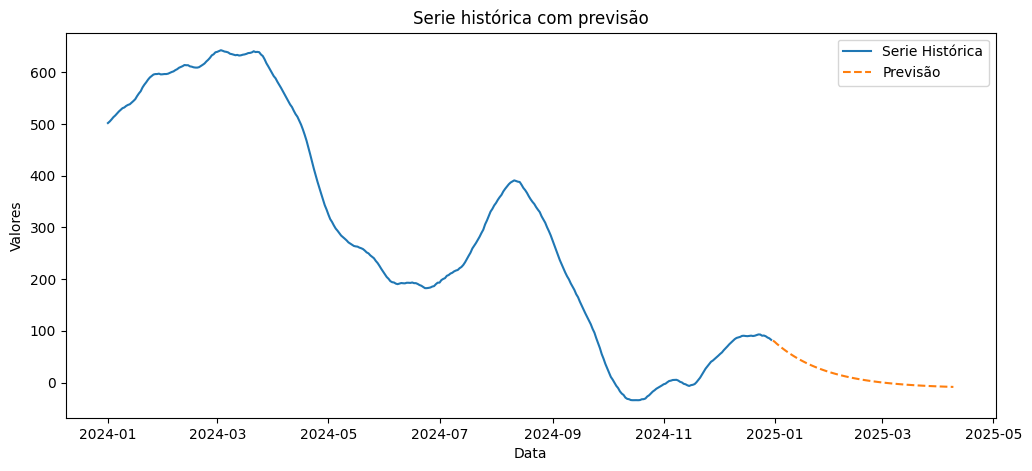

In [6]:
previsao = model.forecast(100)
plot_forecast(Y,previsao)

No Python podemos usar p ou q como tuples: 

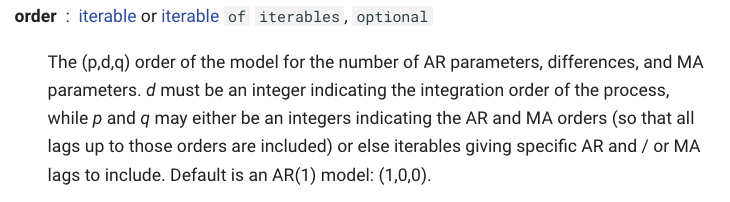

Se quisermos retirar o lag 2 do MA podemos chamar q de (1,0,1)

                                SARIMAX Results                                
Dep. Variable:                   preco   No. Observations:                  365
Model:             ARIMA(2, 1, [1, 3])   Log Likelihood                -514.595
Date:                 Tue, 11 Mar 2025   AIC                           1039.190
Time:                         11:39:55   BIC                           1058.676
Sample:                     01-01-2024   HQIC                          1046.935
                          - 12-30-2024                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5196      0.051     10.279      0.000       0.421       0.619
ar.L2          0.4311      0.051      8.422      0.000       0.331       0.531
ma.L1         -0.0316      0.023     -1.348 

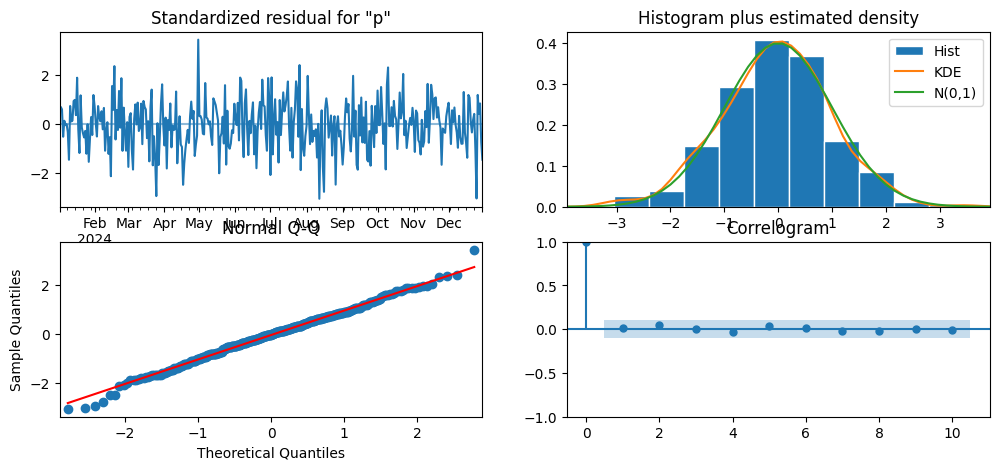

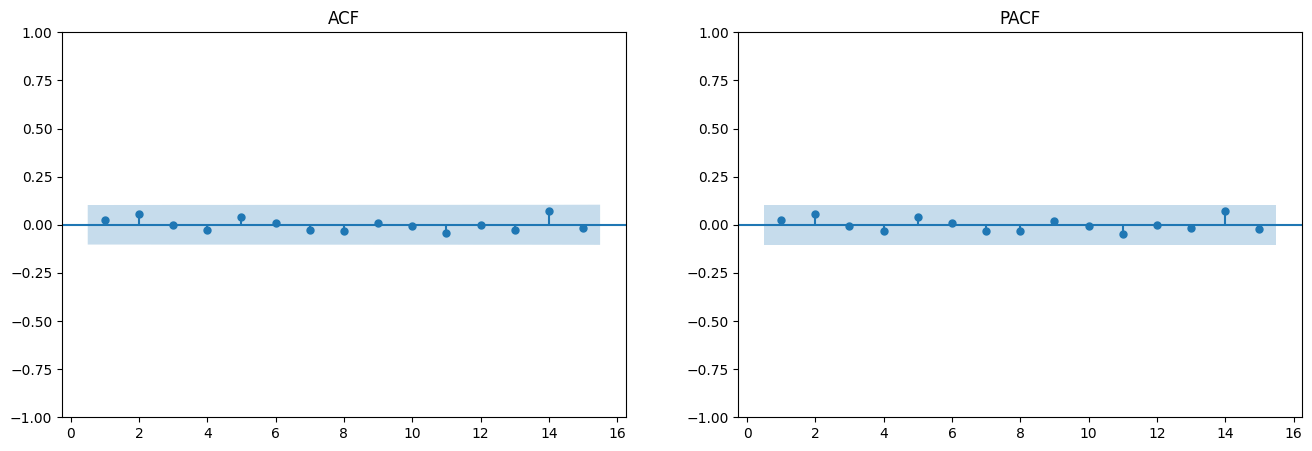

In [7]:
model = ARIMA(Y, order=(2, 1, (1,0,1))).fit()
diagnostico(model)

Da até para tirar mais 1:

                               SARIMAX Results                                
Dep. Variable:                  preco   No. Observations:                  365
Model:               ARIMA(2, 1, [3])   Log Likelihood                -515.275
Date:                Tue, 11 Mar 2025   AIC                           1038.549
Time:                        11:40:32   BIC                           1054.138
Sample:                    01-01-2024   HQIC                          1044.745
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4931      0.047     10.540      0.000       0.401       0.585
ar.L2          0.4567      0.048      9.528      0.000       0.363       0.551
ma.L3          0.9217      0.023     39.346      0.0

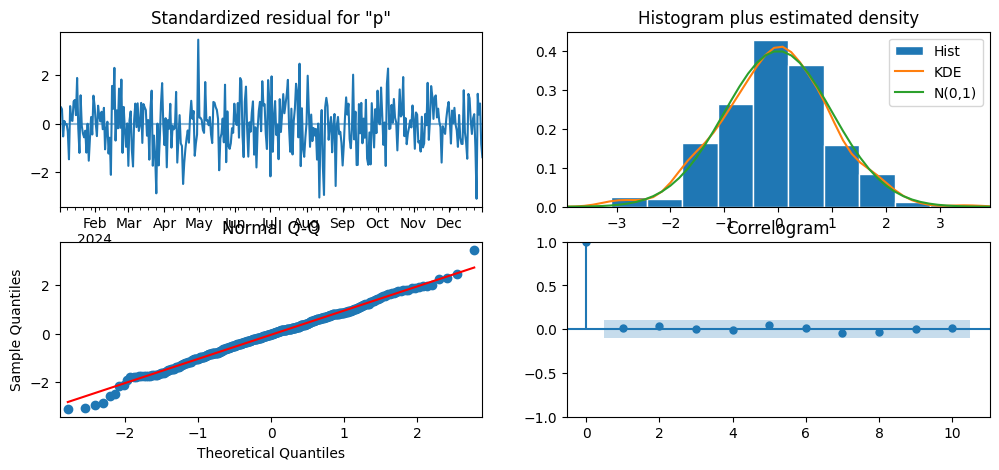

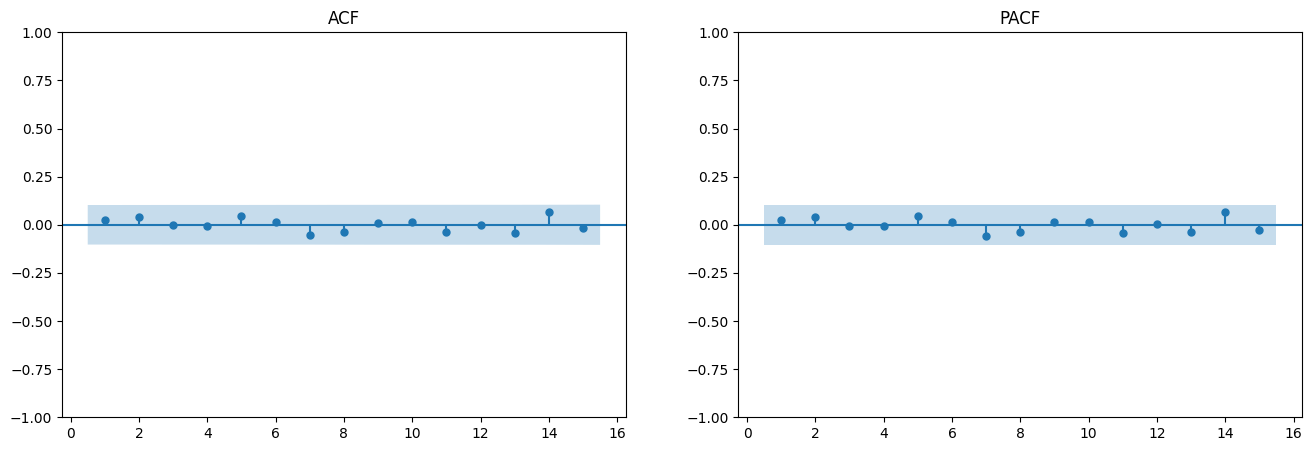

In [8]:
model = ARIMA(Y, order=(2, 1, (0,0,1))).fit()
diagnostico(model)

Reparem que o BIC e o AIC ficaram menores.

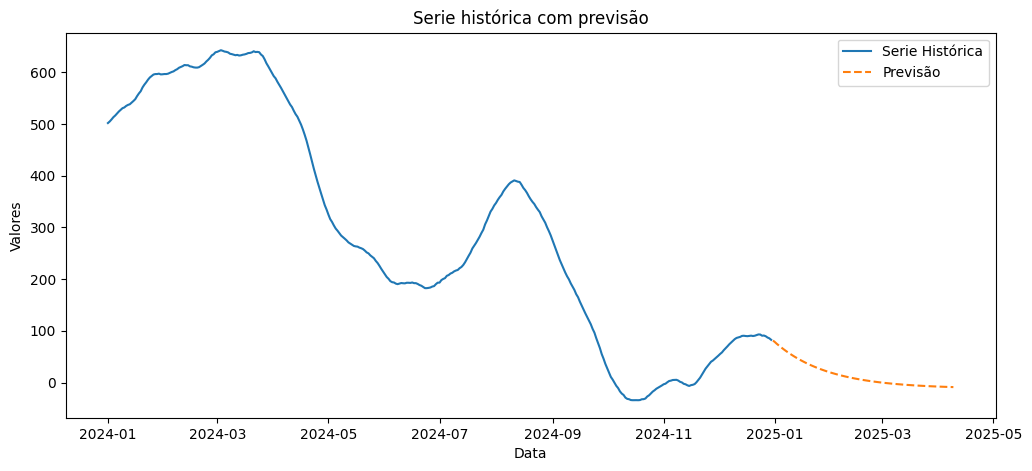

In [9]:
previsao = model.forecast(100)
plot_forecast(Y,previsao)

## Fórmula do modelo:
$$ \large (1 - B) Y_t = 0.493 Y_{t-1} + 0.457 Y_{t-2} + 0.922 \epsilon_{t-3} + \epsilon_t $$

ou

$$ \large Y_t = Y_{t-1} + 0.493 Y_{t-1} + 0.457 Y_{t-2} + 0.922 \epsilon_{t-3} + \epsilon_t $$

## SARIMA
nessa parte vamos tentar aplicar modelos para séries sazonais usando as ferramentas que temos em mão:

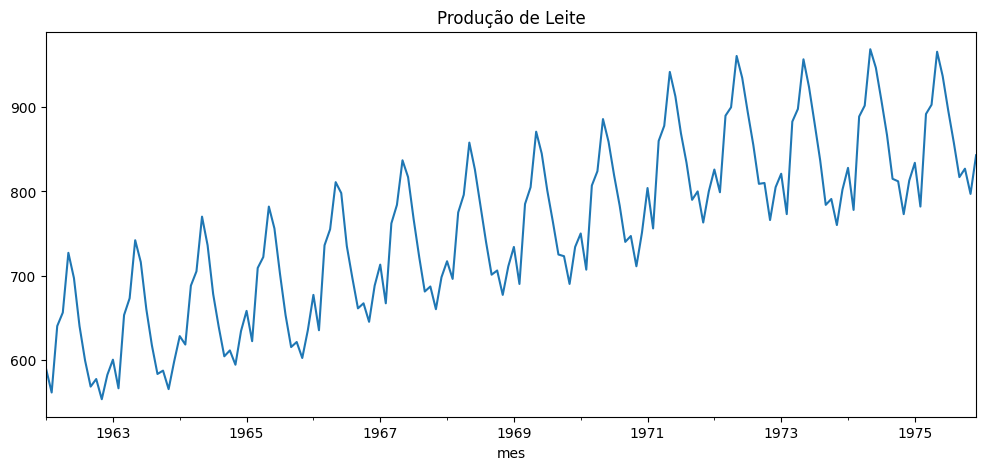

In [12]:
milk = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/milk_production.csv')
milk['mes'] = milk['month']
milk.index = pd.to_datetime(milk['mes'])
milk.index.freq = 'MS'
milk_prod = pd.Series(milk['production'], name="produção de leite")
milk_prod.plot()
plt.title('Produção de Leite')
plt.show()